## Diabetes Readmission Prediction

#### Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImblearnPipeline

import shap

C:\Users\Johnson\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Load Dataset

In [3]:
# Read the dataset
US_diab_readmission = pd.read_csv("../Diabetes Dataset/diabetic_data.csv")

In [4]:
# Load the first 5 rows of the dataset
US_diab_readmission.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
# Load the last 5 rows of the dataset
US_diab_readmission.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


#### Analysing the Dataset

In [6]:
US_diab_readmission.columns.to_list()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

In [7]:
# Observe the datasets size
US_diab_readmission.shape

(101766, 50)

In [8]:
US_diab_readmission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [9]:
# Understanding the datasets statistics
US_diab_readmission.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


#### Data Cleaning & Preprocessing

In [10]:
# Calculating missing values by features
total_missing_val = (US_diab_readmission.isnull().sum()/len(US_diab_readmission)*100)
top_missing_val = total_missing_val[total_missing_val > 0].sort_values(ascending=False)
print(top_missing_val)

max_glu_serum    94.746772
A1Cresult        83.277322
dtype: float64


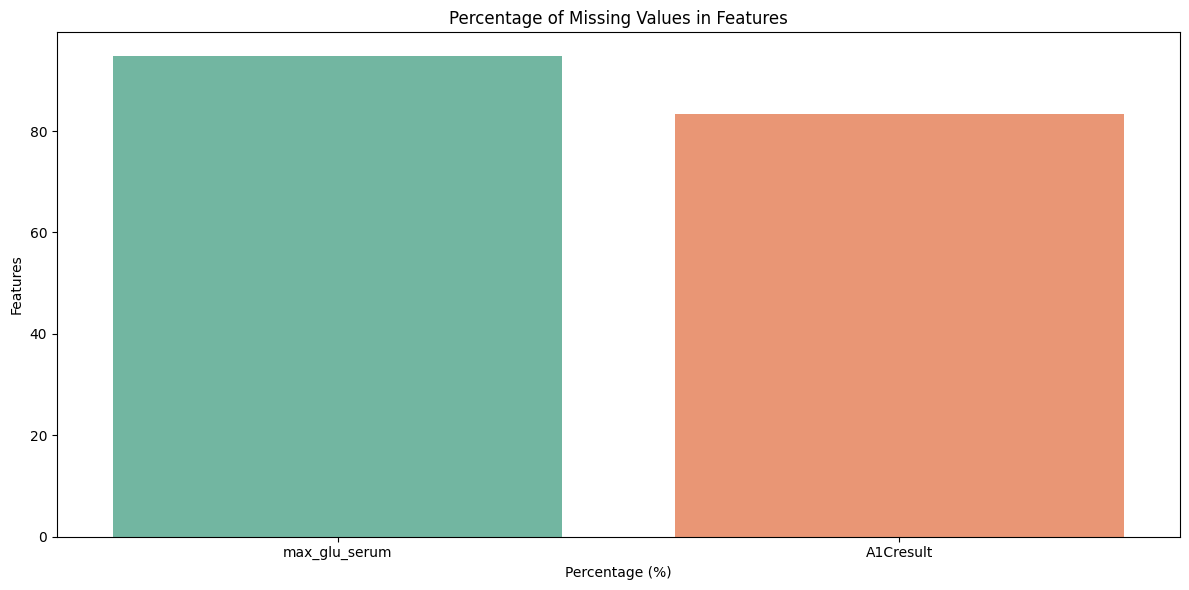

In [11]:
# Visualising missing values by features
plt.figure(figsize=(12,6))
sns.barplot(x=top_missing_val.index, y=top_missing_val, hue=top_missing_val.index, palette="Set2", legend=False)
plt.xlabel("Percentage (%)")
plt.ylabel("Features")
plt.title("Percentage of Missing Values in Features")
plt.tight_layout()
plt.show()

In [12]:
# Features: "max_glu_serum" and "A1Cresult" hold high amounts of "None" data values according to the UCI Repository
# To address this, these columns will need to be encoded
print(US_diab_readmission["max_glu_serum"].value_counts())
print(US_diab_readmission["A1Cresult"].value_counts())

max_glu_serum
Norm    2597
>200    1485
>300    1264
Name: count, dtype: int64
A1Cresult
>8      8216
Norm    4990
>7      3812
Name: count, dtype: int64


In [13]:
# The dataset represents NaN values as "?" character
# Calculating the percentage of "?" characters by features
Character_val = ((US_diab_readmission == "?").sum()/len(US_diab_readmission)*100)
top_character_val = Character_val[Character_val > 0].sort_values(ascending=False)
print(top_character_val)

weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


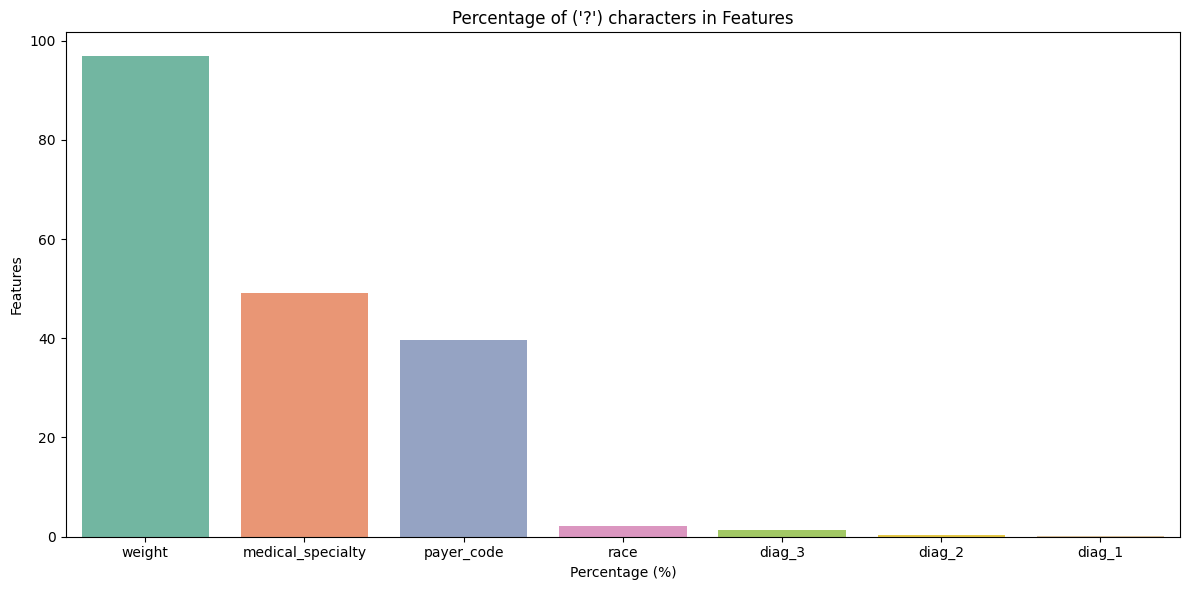

In [14]:
# Visualising the percentage of "?" characters by features
plt.figure(figsize=(12,6))
sns.barplot(x=top_character_val.index, y=top_character_val, hue=top_character_val.index, palette="Set2", legend=False)
plt.xlabel("Percentage (%)")
plt.ylabel("Features")
plt.title("Percentage of ('?') characters in Features")
plt.tight_layout()
plt.show()

In [15]:
# The top 3 features have the highest null values, imputing values into them would not hold any value
# Therefore, they will be dropped
US_diab_readmission = US_diab_readmission.drop(columns=["weight", "medical_specialty", "payer_code"])

In [16]:
#To process the remaining features with null values
#The "?" value needs to be replaced with np.nan
US_diab_readmission = US_diab_readmission.replace("?", np.nan)

In [17]:
# Imputing the remaining columns using Mode.
impute_remaining_col = ["diag_3", "diag_2", "diag_1", "race"]
US_diab_readmission[impute_remaining_col] = US_diab_readmission[impute_remaining_col].fillna(US_diab_readmission[impute_remaining_col].mode().iloc[0])

In [18]:
# Final null value check
US_diab_readmission.isna().sum().sort_values(ascending=False)

max_glu_serum               96420
A1Cresult                   84748
encounter_id                    0
gender                          0
age                             0
patient_nbr                     0
race                            0
admission_source_id             0
time_in_hospital                0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
admission_type_id               0
discharge_disposition_id        0
number_inpatient                0
number_emergency                0
diag_1                          0
diag_2                          0
number_diagnoses                0
diag_3                          0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide                       0
tolbutamide   

In [19]:
# # Final duplicate value check
US_diab_readmission.duplicated().sum()

np.int64(0)

In [20]:
# Features: "encounter_id" and "patient_nbr" are unique indentifiers
# They hold no meaningful value
US_diab_readmission = US_diab_readmission.drop(columns=["encounter_id", "patient_nbr"])

In [21]:
US_diab_readmission.shape

(101766, 45)

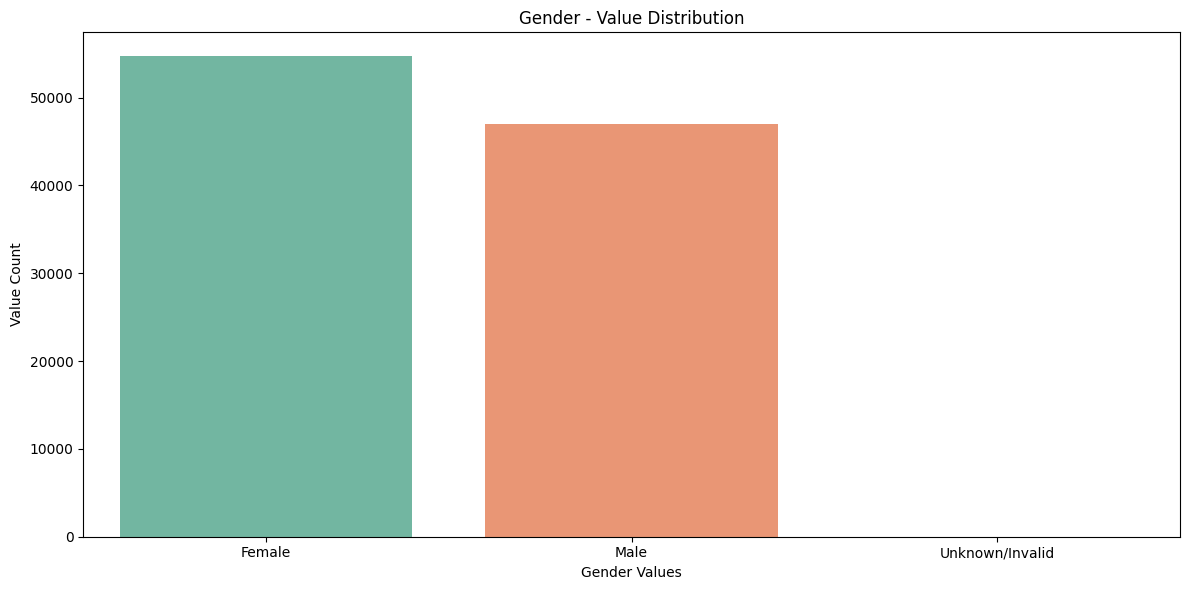

In [22]:
feature_gender = US_diab_readmission["gender"].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=feature_gender.index, y=feature_gender, hue=feature_gender.index, palette="Set2", legend=False)
plt.xlabel("Gender Values")
plt.ylabel("Value Count")
plt.title("Gender - Value Distribution")
plt.tight_layout()
plt.show()

In [23]:
print(US_diab_readmission[US_diab_readmission["gender"] == "Unknown/Invalid"].index)

Index([30506, 75551, 82573], dtype='int64')


In [24]:
# Feature: "gender" has unknown values in it
# Therefore, its better to drop those values
US_diab_readmission = US_diab_readmission.drop(index=[30506, 75551, 82573])

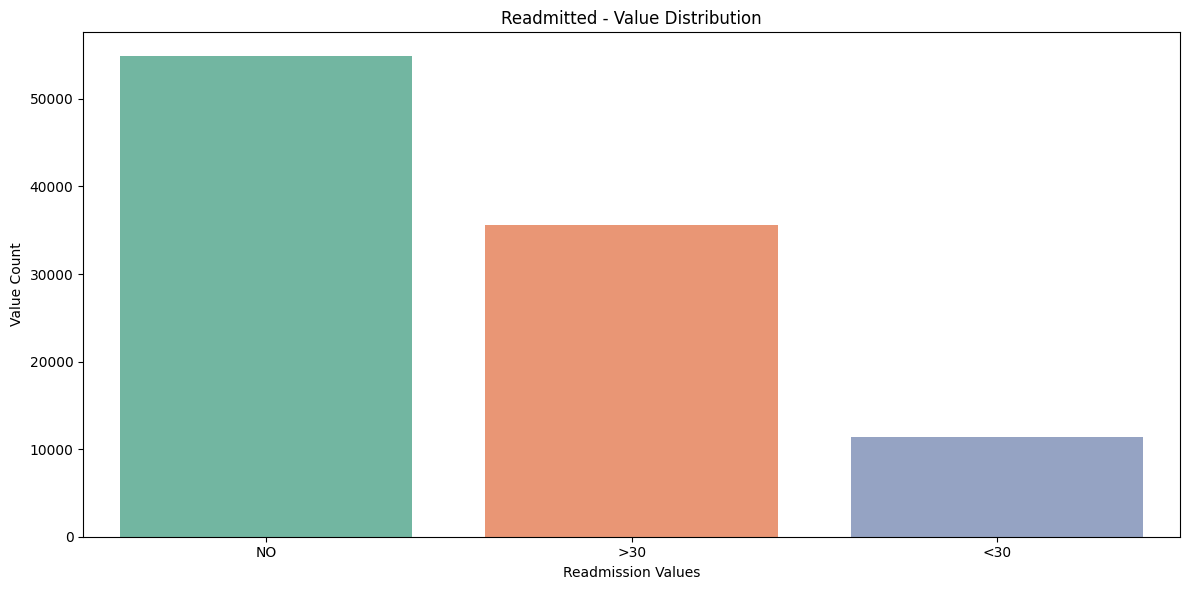

In [25]:
feature_readmission = US_diab_readmission["readmitted"].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=feature_readmission.index, y=feature_readmission, hue=feature_readmission.index, palette="Set2", legend=False)
plt.xlabel("Readmission Values")
plt.ylabel("Value Count")
plt.title("Readmitted - Value Distribution")
plt.tight_layout()
plt.show()

In [26]:
# Feature: "readmitted" values are in categorical format
# Binary formatting will be better for data processing

# Converts "<30" into "1" & ">30" into "0"
US_diab_readmission["readmitted"] = (US_diab_readmission["readmitted"] == "<30").astype(int)

In [27]:
US_diab_readmission["readmitted"].value_counts()

readmitted
0    90406
1    11357
Name: count, dtype: int64

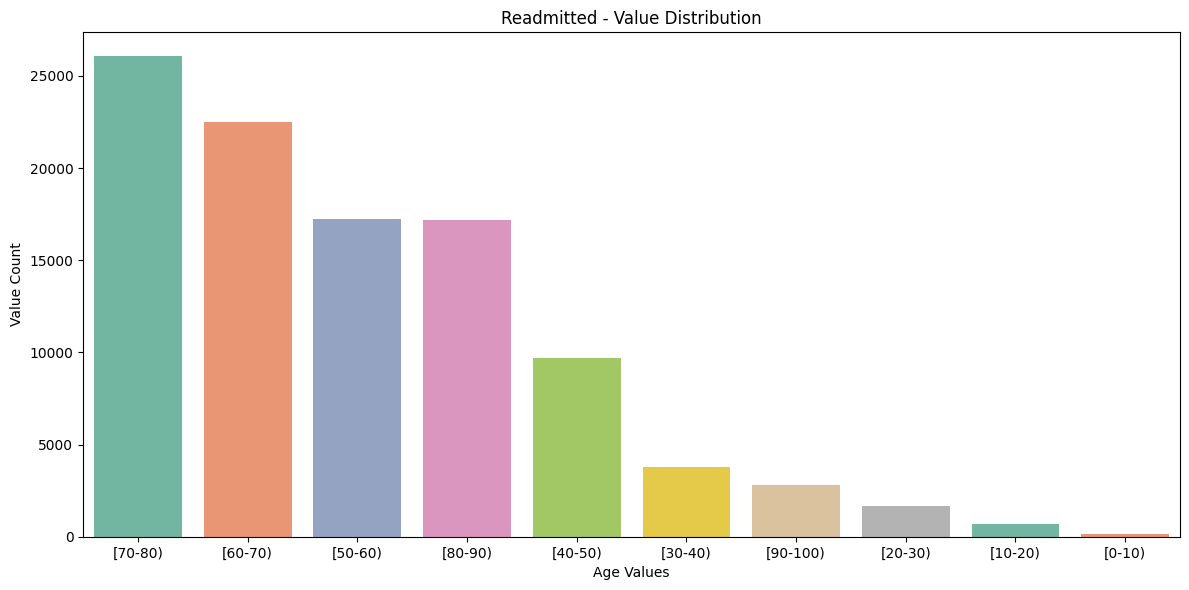

In [28]:
feature_age = US_diab_readmission["age"].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=feature_age.index, y=feature_age, hue=feature_age.index, palette="Set2", legend=False)
plt.xlabel("Age Values")
plt.ylabel("Value Count")
plt.title("Readmitted - Value Distribution")
plt.tight_layout()
plt.show()

In [29]:
# Feature: "age" values are in interval format
# Numerical formatting will be better for data processing

US_diab_readmission["age"] = US_diab_readmission["age"].map({
    "[70-80)": 75,
    "[60-70)": 65,
    "[50-60)": 55,
    "[80-90)": 85,
    "[40-50)": 45,
    "[30-40)": 35,
    "[90-100)": 95,
    "[20-30)": 25,
    "[10-20)": 15,
    "[0-10)": 5
})

In [30]:
print(US_diab_readmission["age"])

0          5
1         15
2         25
3         35
4         45
          ..
101761    75
101762    85
101763    75
101764    85
101765    75
Name: age, Length: 101763, dtype: int64


#### Exploratory Data Analysis

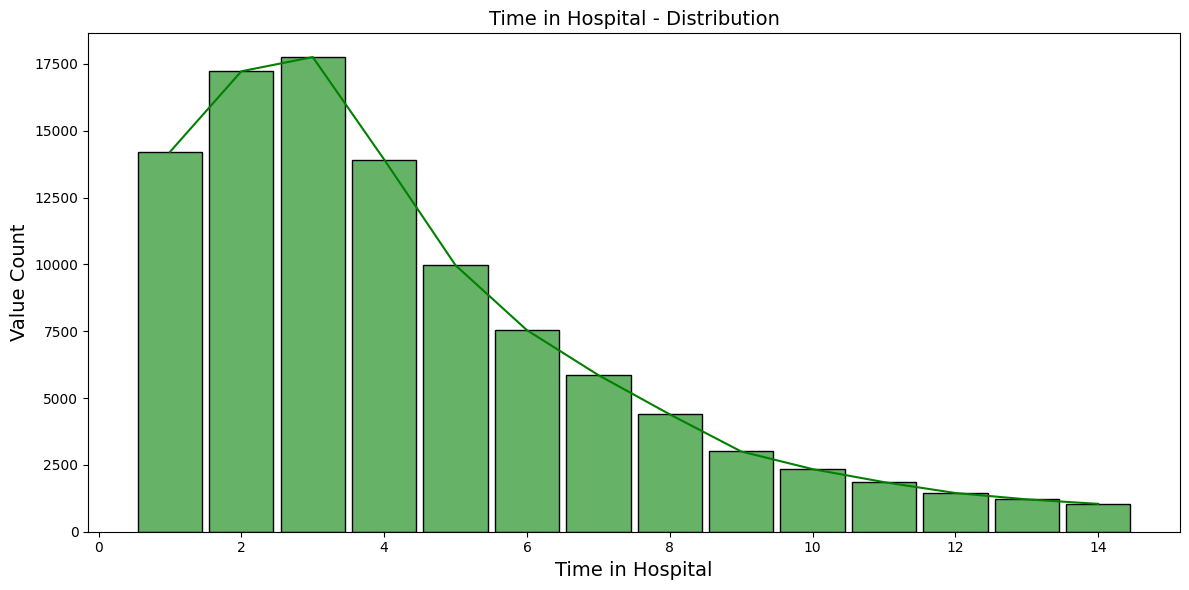

In [31]:
time_in_hosp_val = US_diab_readmission["time_in_hospital"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.histplot(data=US_diab_readmission, x="time_in_hospital", discrete=True, color="green", shrink=0.9, alpha=0.6)
plt.plot(time_in_hosp_val.index, time_in_hosp_val.values, color="green")
plt.xlabel("Time in Hospital", fontsize=14)
plt.ylabel("Value Count", fontsize=14)
plt.title("Time in Hospital - Distribution", fontsize=14)
plt.tight_layout()
plt.show()

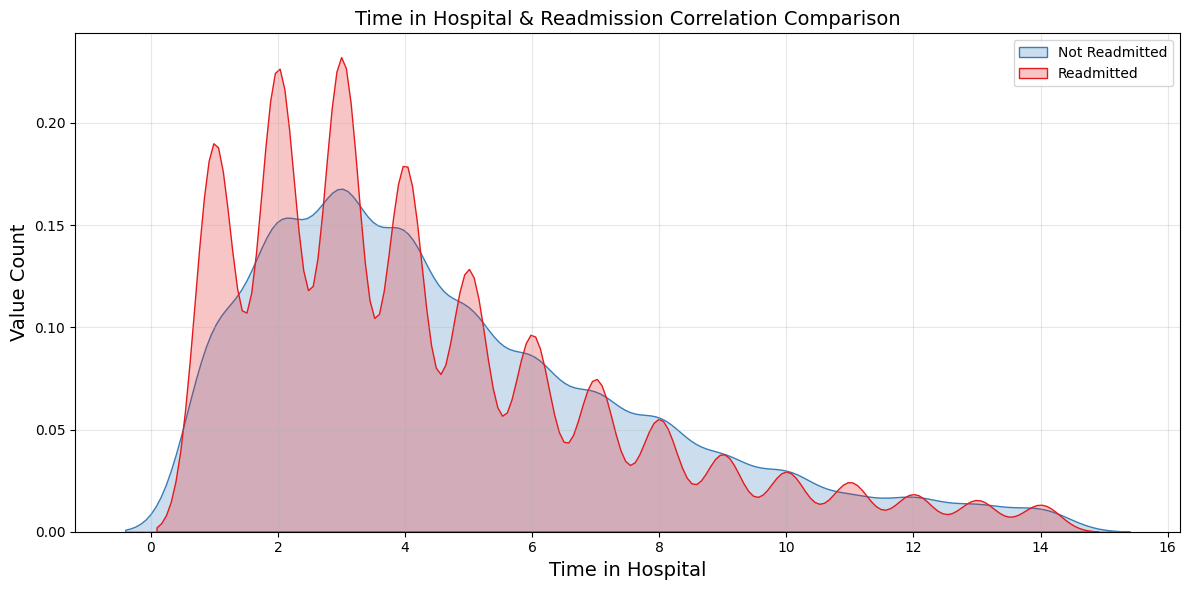

In [32]:
plt.figure(figsize= (12, 6))
sns.kdeplot(data=US_diab_readmission, x="time_in_hospital", hue="readmitted", palette="Set1", common_norm=False, fill=True)
plt.xlabel("Time in Hospital", fontsize=14)
plt.ylabel("Value Count", fontsize=14)
plt.title("Time in Hospital & Readmission Correlation Comparison", fontsize=14)
plt.tight_layout()
plt.legend(labels=["Not Readmitted", "Readmitted"])
plt.grid(True, alpha=0.3)
plt.show()

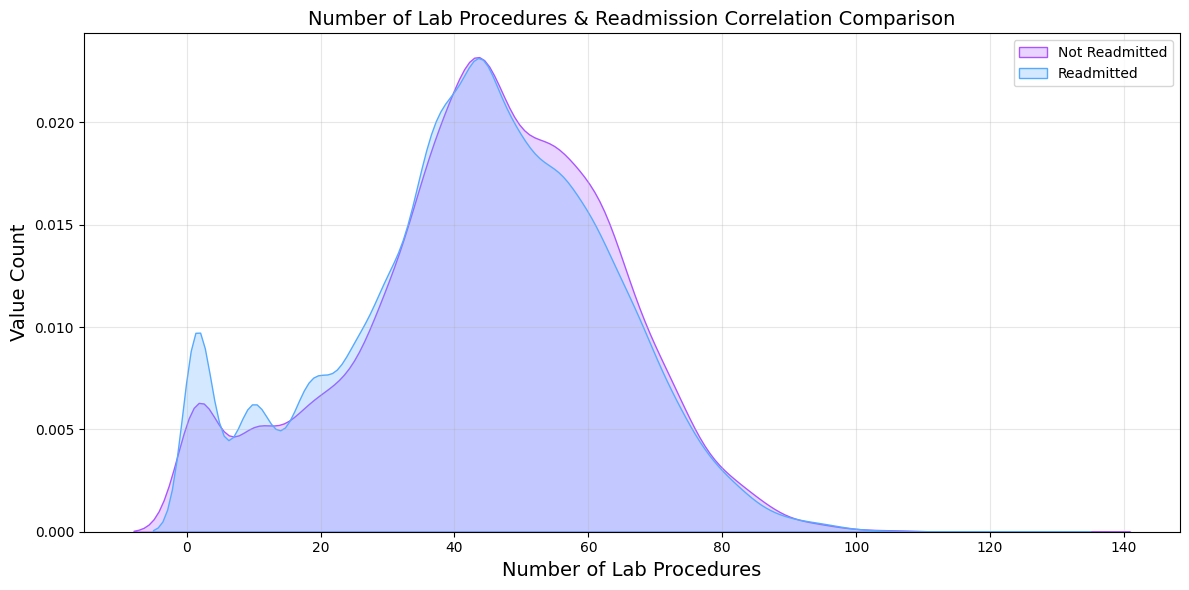

In [33]:
plt.figure(figsize= (12, 6))
sns.kdeplot(data=US_diab_readmission, x="num_lab_procedures", hue="readmitted", palette="cool", common_norm=False, fill=True)
plt.xlabel("Number of Lab Procedures", fontsize=14)
plt.ylabel("Value Count", fontsize=14)
plt.title("Number of Lab Procedures & Readmission Correlation Comparison", fontsize=14)
plt.tight_layout()
plt.legend(labels=["Not Readmitted", "Readmitted"])
plt.grid(True, alpha=0.3)
plt.show()

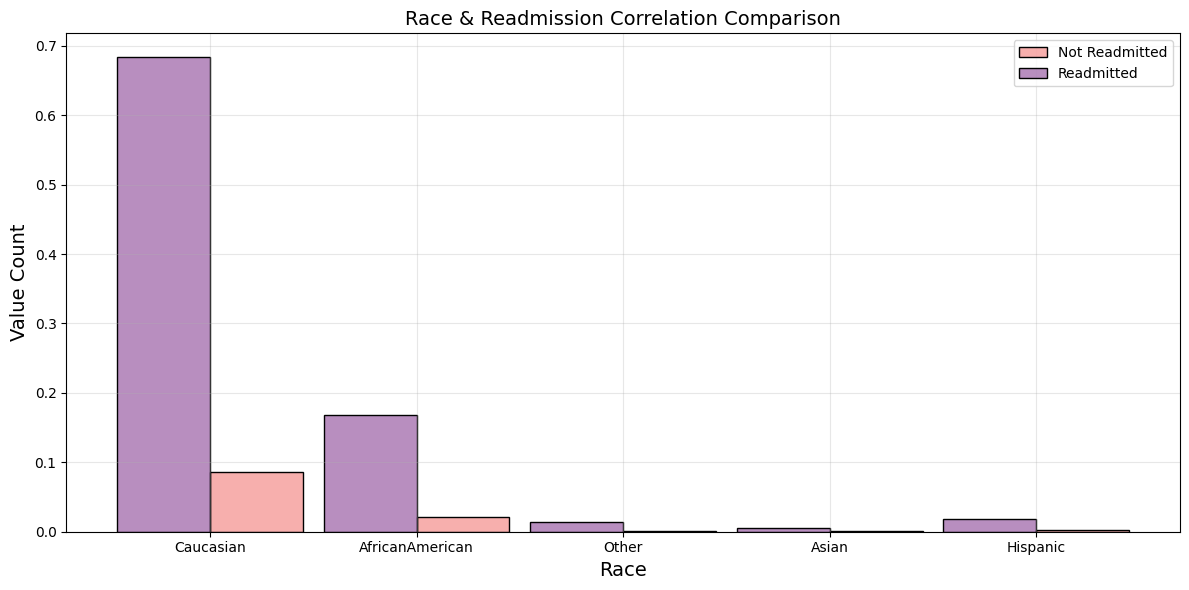

In [34]:
plt.figure(figsize= (12, 6))
sns.histplot(data=US_diab_readmission, x="race", hue="readmitted", palette="magma", discrete=True, shrink=0.9, alpha=0.5, stat="proportion", multiple="dodge")
plt.xlabel("Race", fontsize=14)
plt.ylabel("Value Count", fontsize=14)
plt.title("Race & Readmission Correlation Comparison", fontsize=14)
plt.tight_layout()
plt.legend(labels=["Not Readmitted", "Readmitted"])
plt.grid(True, alpha=0.3)
plt.show()

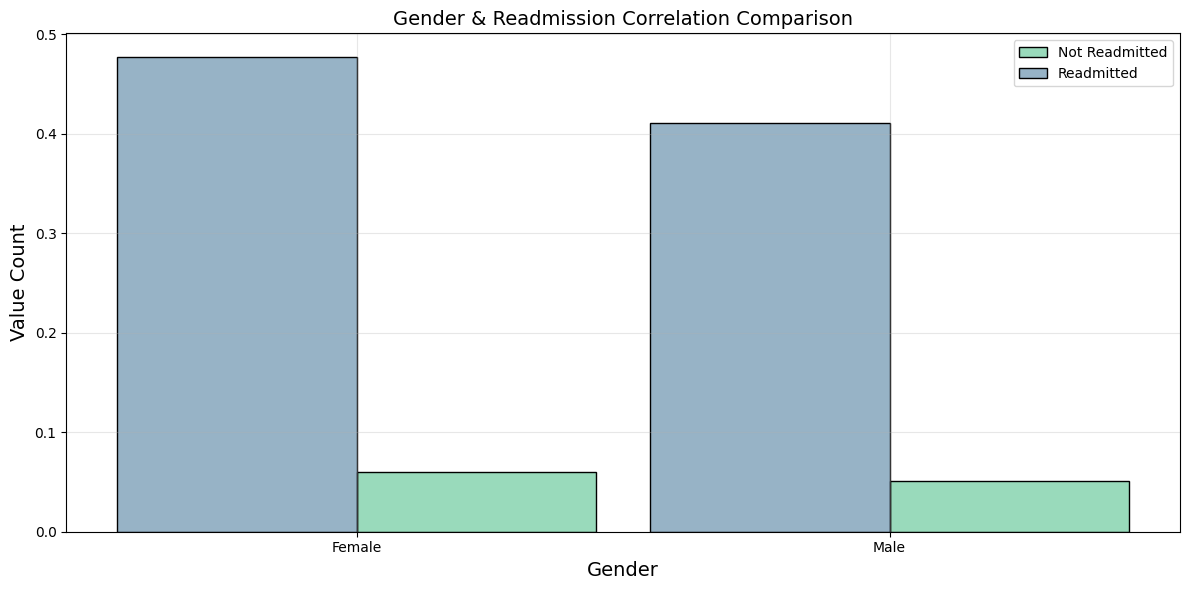

In [35]:
plt.figure(figsize= (12, 6))
sns.histplot(data=US_diab_readmission, x="gender", hue="readmitted", palette="viridis", discrete=True, shrink=0.9, alpha=0.5, stat="proportion", multiple="dodge")
plt.xlabel("Gender", fontsize=14)
plt.ylabel("Value Count", fontsize=14)
plt.title("Gender & Readmission Correlation Comparison", fontsize=14)
plt.tight_layout()
plt.legend(labels=["Not Readmitted", "Readmitted"])
plt.grid(True, alpha=0.3)
plt.show()

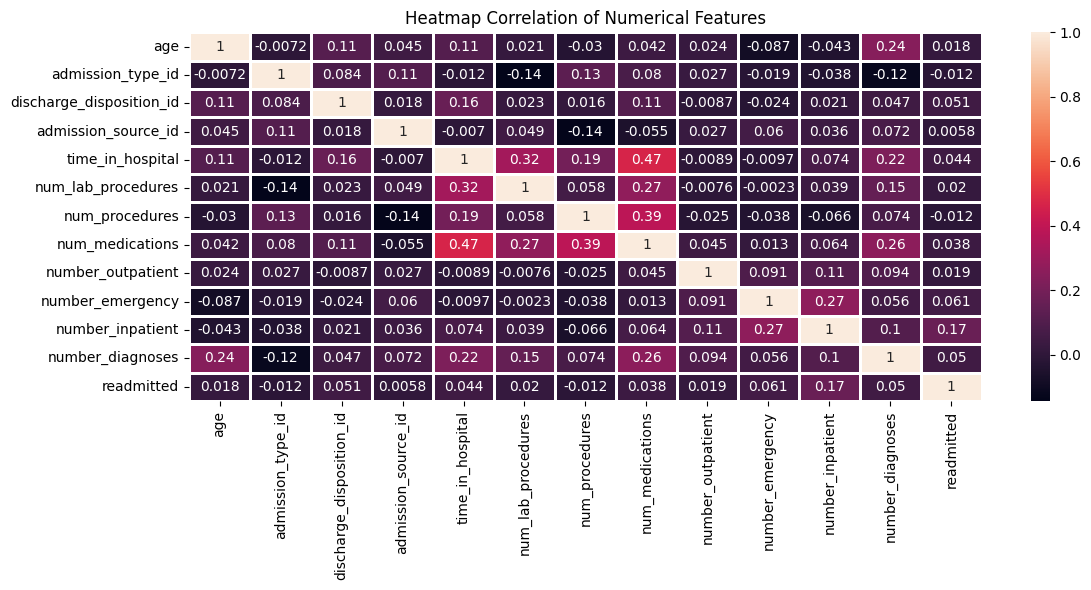

In [36]:
# Visualising numeric feature correlation - Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(US_diab_readmission.corr(numeric_only=True), annot=True, linewidths=1)
plt.title("Heatmap Correlation of Numerical Features")
plt.tight_layout()
plt.show()

#### Feature Encoding

In [37]:
# Changing the NaN values into "None" string, before encoding
US_diab_readmission["max_glu_serum"] = US_diab_readmission["max_glu_serum"].fillna("None")
US_diab_readmission["A1Cresult"] = US_diab_readmission["A1Cresult"].fillna("None")

In [38]:
# Redefining the values in this feature
US_diab_readmission["max_glu_serum"] = US_diab_readmission["max_glu_serum"].map({
    "None": 0,
    "Norm": 1,
    ">200": 2,
    ">300": 3
})
print(US_diab_readmission["max_glu_serum"].value_counts())

max_glu_serum
0    96417
1     2597
2     1485
3     1264
Name: count, dtype: int64


In [39]:
# Redefining the values in this feature
US_diab_readmission["A1Cresult"] = US_diab_readmission["A1Cresult"].map({
    "None": 0,
    "Norm": 1,
    ">7": 2,
    ">8": 3
})
print(US_diab_readmission["A1Cresult"].value_counts())

A1Cresult
0    84745
3     8216
1     4990
2     3812
Name: count, dtype: int64


In [40]:
# Viewing all feature data types
print(US_diab_readmission.dtypes)

race                        object
gender                      object
age                          int64
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum                int64
A1Cresult                    int64
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride                 object
acetohexamide               object
glipizide                   object
glyburide                   object
tolbutamide                 object
pioglitazone        

In [41]:
# Listing all "object" dtypes before encoding
categorical_cols = US_diab_readmission.select_dtypes(include="object").columns
print(categorical_cols)

Index(['race', 'gender', 'diag_1', 'diag_2', 'diag_3', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='object')


In [42]:
# Using One Hot encoding to convert the remaining "object" dtypes
US_diab_encoded = pd.get_dummies(US_diab_readmission, columns=categorical_cols, drop_first=True)
print(US_diab_encoded.head())

   age  admission_type_id  discharge_disposition_id  admission_source_id  \
0    5                  6                        25                    1   
1   15                  1                         1                    7   
2   25                  1                         1                    7   
3   35                  1                         1                    7   
4   45                  1                         1                    7   

   time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
0                 1                  41               0                1   
1                 3                  59               0               18   
2                 2                  11               5               13   
3                 2                  44               1               16   
4                 1                  51               0                8   

   number_outpatient  number_emergency  ...  insulin_Up  \
0                  0       

In [43]:
print(US_diab_encoded.dtypes)

age                                int64
admission_type_id                  int64
discharge_disposition_id           int64
admission_source_id                int64
time_in_hospital                   int64
                                   ...  
glimepiride-pioglitazone_Steady     bool
metformin-rosiglitazone_Steady      bool
metformin-pioglitazone_Steady       bool
change_No                           bool
diabetesMed_Yes                     bool
Length: 2320, dtype: object


In [44]:
bool_val_col = US_diab_encoded.select_dtypes(include= "bool").columns
print(bool_val_col)

Index(['race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other',
       'gender_Male', 'diag_1_11', 'diag_1_110', 'diag_1_112', 'diag_1_114',
       'diag_1_115',
       ...
       'insulin_Up', 'glyburide-metformin_No', 'glyburide-metformin_Steady',
       'glyburide-metformin_Up', 'glipizide-metformin_Steady',
       'glimepiride-pioglitazone_Steady', 'metformin-rosiglitazone_Steady',
       'metformin-pioglitazone_Steady', 'change_No', 'diabetesMed_Yes'],
      dtype='object', length=2305)


In [45]:
# Converting "bool" dtypes into numerical dtypes
for col in US_diab_encoded.select_dtypes(include= ["bool"]).columns:
    US_diab_encoded[col] = US_diab_encoded[col].astype(int)

# Final bool value check
print(US_diab_encoded.dtypes)

age                                int64
admission_type_id                  int64
discharge_disposition_id           int64
admission_source_id                int64
time_in_hospital                   int64
                                   ...  
glimepiride-pioglitazone_Steady    int64
metformin-rosiglitazone_Steady     int64
metformin-pioglitazone_Steady      int64
change_No                          int64
diabetesMed_Yes                    int64
Length: 2320, dtype: object


#### Model Training and Testing

In [46]:
X = US_diab_encoded.drop("readmitted", axis=1)
y = US_diab_encoded["readmitted"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((81410, 2319), (20353, 2319), (81410,), (20353,))

#### Logistic Regression

##### Case 1: StandardScaler

In [49]:
# Applying feature scaling via StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
# Model #1 - Training Logistic Regression
log_reg_base = LogisticRegression(max_iter=10000, random_state=42)
log_reg_base.fit(X_train_scaled, y_train)

log_reg_base_prediction = log_reg_base.predict(X_test_scaled)
log_reg_base_probability = log_reg_base.predict_proba(X_test_scaled)[:, 1]
log_reg_base_accuracy = accuracy_score(y_test, log_reg_base_prediction) *100

print(f"Model 1 - Logistic Regression (StandardScaler): {log_reg_base_accuracy:.2f}%")
print("\n Classification Report")
print(classification_report(y_test, log_reg_base_prediction))

Model 1 - Logistic Regression (StandardScaler): 88.71%

 Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.39      0.02      0.04      2271

    accuracy                           0.89     20353
   macro avg       0.64      0.51      0.49     20353
weighted avg       0.83      0.89      0.84     20353



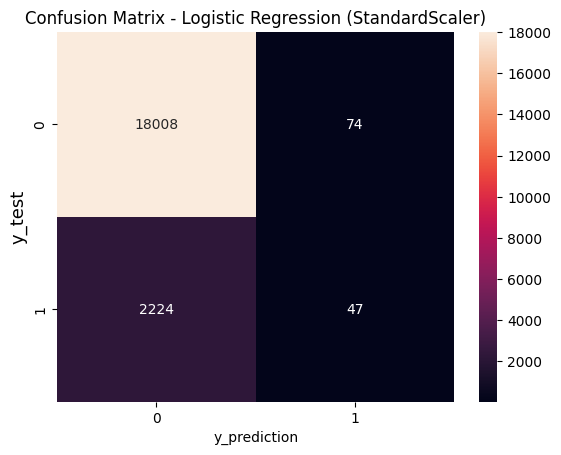

In [51]:
# Visualising Confusion Matrix
confuse_mat = confusion_matrix(y_test, log_reg_base_prediction)
sns.heatmap(confuse_mat, annot=True, fmt="g")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - Logistic Regression (StandardScaler)")
plt.show()

AUC-ROC Score: 0.63%


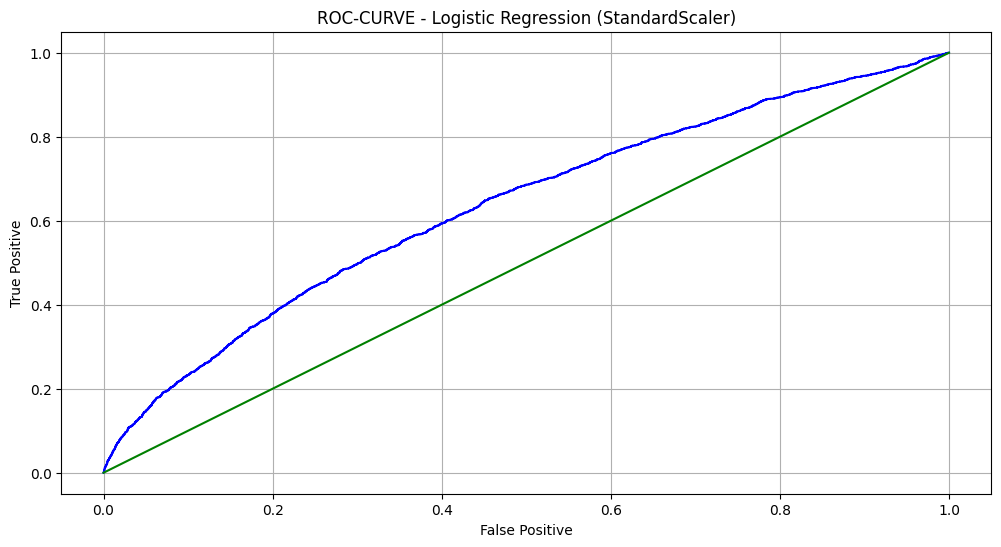

In [52]:
# Visualising AUC-ROC Curve
auc_score = roc_auc_score(y_test, log_reg_base_probability)
print(f"AUC-ROC Score: {auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, log_reg_base_probability)

plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, color="blue", label=f"Logistic Regression (StandardScaler) (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - Logistic Regression (StandardScaler)")
plt.grid(True)
plt.show()

##### Case 2: StandardScaler + SMOTE

In [53]:
# Applying feature scaling via StandardScaler
# Applying SMOTE to address data imbalance
scaler_smote_lg = StandardScaler()
smote_lg = SMOTE(random_state=42)

X_train_scaled_smote_lg = scaler_smote_lg.fit_transform(X_train)
X_test_scaled_smote_lg = scaler_smote_lg.transform(X_test)


X_train_smote, y_train_smote = smote_lg.fit_resample(X_train_scaled_smote_lg, y_train)

In [54]:
# Model #1 - Training Logistic Regression
log_reg_base_smote = LogisticRegression(max_iter=10000, random_state=42)
log_reg_base_smote.fit(X_train_smote, y_train_smote)

log_reg_base_smote_prediction = log_reg_base_smote.predict(X_test_scaled_smote_lg)
log_reg_base_smote_probability = log_reg_base_smote.predict_proba(X_test_scaled_smote_lg)[:, 1]
log_reg_base_smote_accuracy = accuracy_score(y_test, log_reg_base_smote_prediction) *100

print(f"Model 1 - Logistic Regression (StandardScaler + SMOTE): {log_reg_base_smote_accuracy:.2f}%")
print("\n Classification Report")
print(classification_report(y_test, log_reg_base_smote_prediction))

Model 1 - Logistic Regression (StandardScaler + SMOTE): 63.02%

 Classification Report
              precision    recall  f1-score   support

           0       0.92      0.64      0.75     18082
           1       0.16      0.55      0.25      2271

    accuracy                           0.63     20353
   macro avg       0.54      0.60      0.50     20353
weighted avg       0.83      0.63      0.70     20353



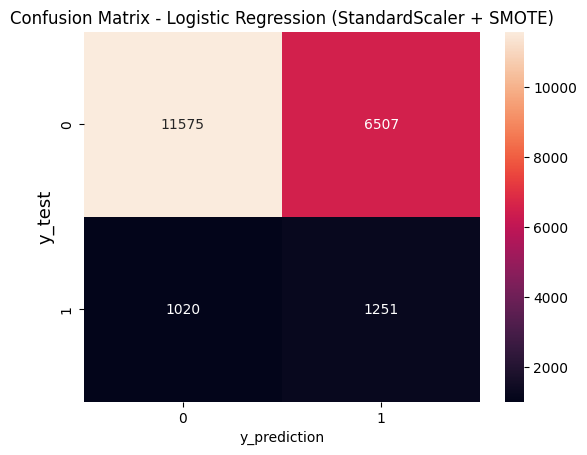

In [55]:
# Visualising Confusion Matrix
confuse_mat = confusion_matrix(y_test, log_reg_base_smote_prediction)
sns.heatmap(confuse_mat, annot=True, fmt="g")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - Logistic Regression (StandardScaler + SMOTE)")
plt.show()

AUC-ROC Score: 0.63%


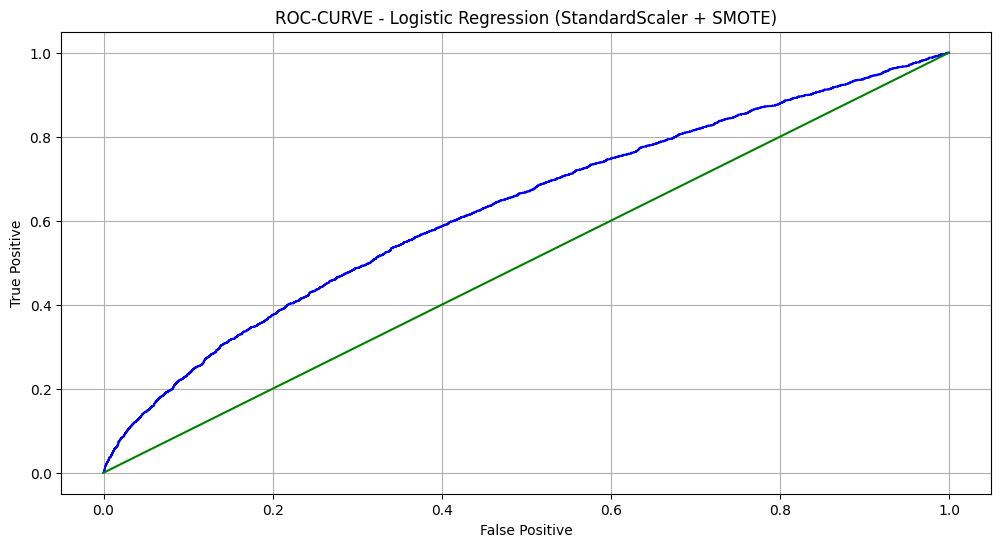

In [56]:
# Visualising AUC-ROC Curve
auc_score = roc_auc_score(y_test, log_reg_base_smote_probability)
print(f"AUC-ROC Score: {auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, log_reg_base_smote_probability)

plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, color="blue", label=f"Logistic Regression (StandardScaler + SMOTE) (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - Logistic Regression (StandardScaler + SMOTE)")
plt.grid(True)
plt.show()

#### Random Forest

##### Case 1: StandardScaler

In [57]:
# Applying feature scaling via StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
# Model #2 - Training Random Forest
rand_forest_base = RandomForestClassifier(random_state=42)
rand_forest_base.fit(X_train_scaled, y_train)

rand_forest_base_prediction = rand_forest_base.predict(X_test_scaled)
rand_forest_base_probability = rand_forest_base.predict_proba(X_test_scaled)[:, 1]
rand_forest_base_accuracy = accuracy_score(y_test, rand_forest_base_prediction) *100

print(f"Model 2 - Random Forest (StandardScaler): {rand_forest_base_accuracy:.2f}%")
print("\n Classification Report")
print(classification_report(y_test, rand_forest_base_prediction))

Model 2 - Random Forest (StandardScaler): 88.90%

 Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.88      0.01      0.01      2271

    accuracy                           0.89     20353
   macro avg       0.88      0.50      0.48     20353
weighted avg       0.89      0.89      0.84     20353



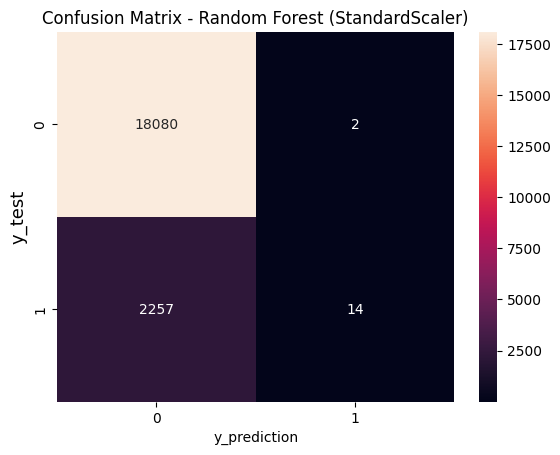

In [59]:
# Visualising Confusion Matrix
confuse_mat = confusion_matrix(y_test, rand_forest_base_prediction)
sns.heatmap(confuse_mat, annot=True, fmt="g")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - Random Forest (StandardScaler)")
plt.show()

AUC-ROC Score: 0.64%


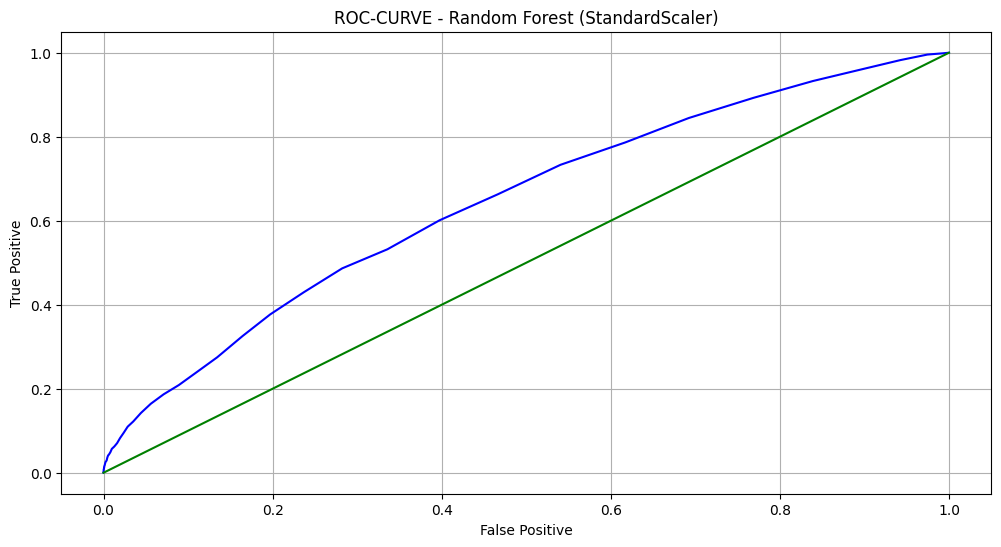

In [60]:
# Visualising AUC-ROC Curve
auc_score = roc_auc_score(y_test, rand_forest_base_probability)
print(f"AUC-ROC Score: {auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, rand_forest_base_probability)

plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, color="blue", label=f"Random Forest (StandardScaler) (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - Random Forest (StandardScaler)")
plt.grid(True)
plt.show()

##### Case 2: StandardScaler + SMOTE

In [61]:
# Applying feature scaling via StandardScaler
# Applying SMOTE to address data imbalance
scaler_smote_rf = StandardScaler()
smote_rf = SMOTE(random_state=42)

X_train_scaled_smote_rf = scaler_smote_rf.fit_transform(X_train)
X_test_scaled_smote_rf = scaler_smote_rf.transform(X_test)


X_train_smote, y_train_smote = smote_rf.fit_resample(X_train_scaled_smote_rf, y_train)

In [62]:
# Model #2 - Training Random Forest
rand_forest_base_smote = RandomForestClassifier(random_state=42)
rand_forest_base_smote.fit(X_train_smote, y_train_smote)

rand_forest_base_smote_prediction = rand_forest_base_smote.predict(X_test_scaled_smote_rf)
rand_forest_base_smote_probability = rand_forest_base_smote.predict_proba(X_test_scaled_smote_rf)[:, 1]
rand_forest_base_smote_accuracy = accuracy_score(y_test, rand_forest_base_smote_prediction) *100

print(f"Model 2 - Random Forest (StandardScaler + SMOTE): {rand_forest_base_smote_accuracy:.2f}%")
print("\n Classification Report")
print(classification_report(y_test, rand_forest_base_smote_prediction))

Model 2 - Random Forest (StandardScaler + SMOTE): 88.88%

 Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.64      0.01      0.01      2271

    accuracy                           0.89     20353
   macro avg       0.76      0.50      0.48     20353
weighted avg       0.86      0.89      0.84     20353



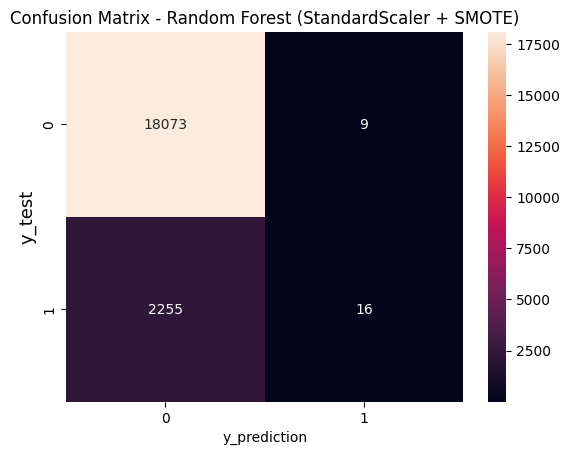

In [63]:
# Visualising Confusion Matrix
confuse_mat = confusion_matrix(y_test, rand_forest_base_smote_prediction)
sns.heatmap(confuse_mat, annot=True, fmt="g")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - Random Forest (StandardScaler + SMOTE)")
plt.show()

AUC-ROC Score: 0.63%


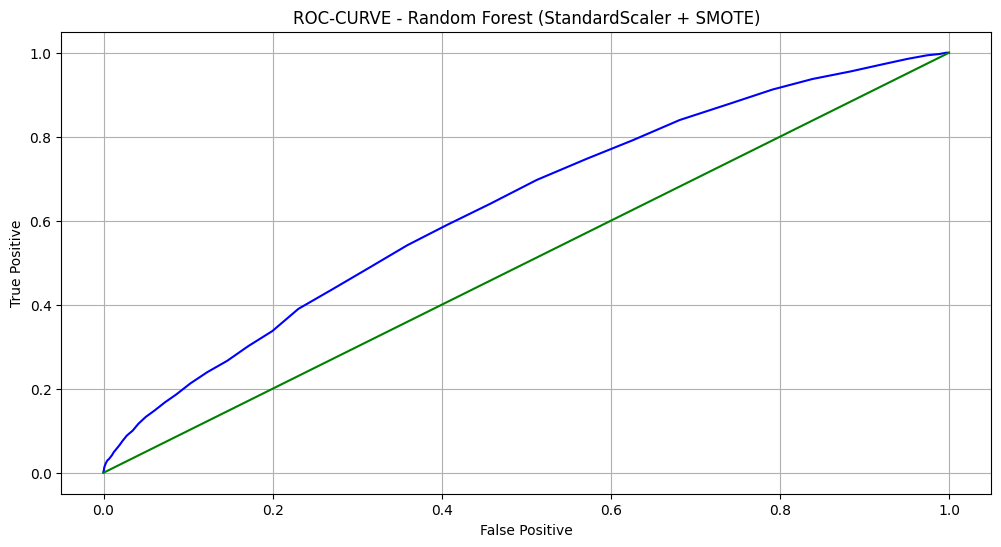

In [64]:
# Visualising AUC-ROC Curve
auc_score = roc_auc_score(y_test, rand_forest_base_smote_probability)
print(f"AUC-ROC Score: {auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, rand_forest_base_smote_probability)

plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, color="blue", label=f"Random Forest (StandardScaler + SMOTE) (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - Random Forest (StandardScaler + SMOTE)")
plt.grid(True)
plt.show()

#### XGBoost

##### Case 1: StandardScaler

In [65]:
# Applying feature scaling via StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
# Model #3 - Training XGBoost
XGB_base = xgb.XGBClassifier(random_state=42, eval_metric="logloss")
XGB_base.fit(X_train_scaled, y_train)

XGB_base_prediction = XGB_base.predict(X_test_scaled)
XGB_base_probability = XGB_base.predict_proba(X_test_scaled)[:, 1]
XGB_base_accuracy = accuracy_score(y_test, XGB_base_prediction) *100

print(f"Model 3 - XGBoost (StandardScaler): {XGB_base_accuracy:.2f}%")
print("\n Classification Report")
print(classification_report(y_test, XGB_base_prediction))

Model 3 - XGBoost (StandardScaler): 88.83%

 Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.49      0.02      0.04      2271

    accuracy                           0.89     20353
   macro avg       0.69      0.51      0.49     20353
weighted avg       0.85      0.89      0.84     20353



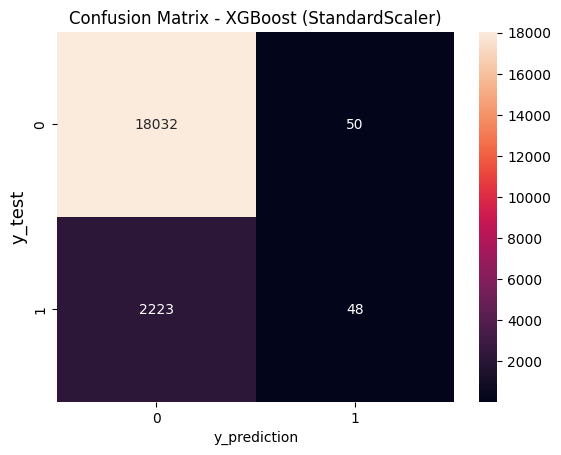

In [67]:
# Visualising Confusion Matrix
confuse_mat = confusion_matrix(y_test, XGB_base_prediction)
sns.heatmap(confuse_mat, annot=True, fmt="g")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - XGBoost (StandardScaler)")
plt.show()

AUC-ROC Score: 0.68%


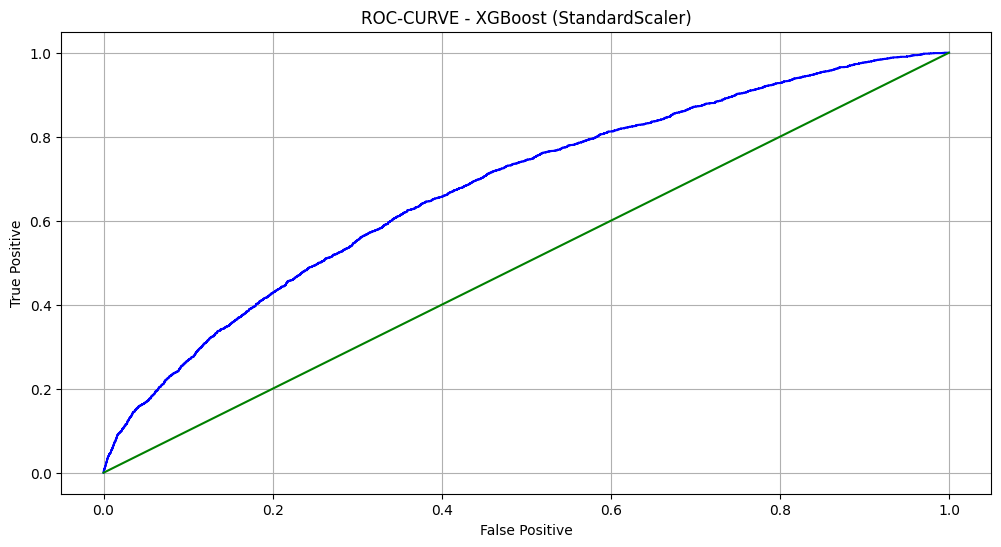

In [68]:
# Visualising AUC-ROC Curve
auc_score = roc_auc_score(y_test, XGB_base_probability)
print(f"AUC-ROC Score: {auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, XGB_base_probability)

plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, color="blue", label=f"XGBoost (StandardScaler) (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - XGBoost (StandardScaler)")
plt.grid(True)
plt.show()

##### Case 2: StandardScaler + SMOTE

In [69]:
# Applying feature scaling via StandardScaler
# Applying SMOTE to address data imbalance
scaler_smote_xgb = StandardScaler()
smote_xgb = SMOTE(random_state=42)

X_train_scaled_smote_xgb = scaler_smote_xgb.fit_transform(X_train)
X_test_scaled_smote_xgb = scaler_smote_xgb.transform(X_test)


X_train_smote, y_train_smote = smote_xgb.fit_resample(X_train_scaled_smote_xgb, y_train)

In [70]:
# Model #3 - Training XGBoost
XGB_base_smote = xgb.XGBClassifier(random_state=42, eval_metric="logloss")
XGB_base_smote.fit(X_train_smote, y_train_smote)

XGB_base_smote_prediction = XGB_base_smote.predict(X_test_scaled_smote_xgb)
XGB_base_smote_probability = XGB_base_smote.predict_proba(X_test_scaled_smote_xgb)[:, 1]
XGB_base_smote_accuracy = accuracy_score(y_test, XGB_base_smote_prediction) *100

print(f"Model 3 - XGBoost (StandardScaler + SMOTE): {XGB_base_smote_accuracy:.2f}%")
print("\n Classification Report")
print(classification_report(y_test, XGB_base_smote_prediction))

Model 3 - XGBoost (StandardScaler + SMOTE): 88.88%

 Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.54      0.02      0.04      2271

    accuracy                           0.89     20353
   macro avg       0.72      0.51      0.49     20353
weighted avg       0.85      0.89      0.84     20353



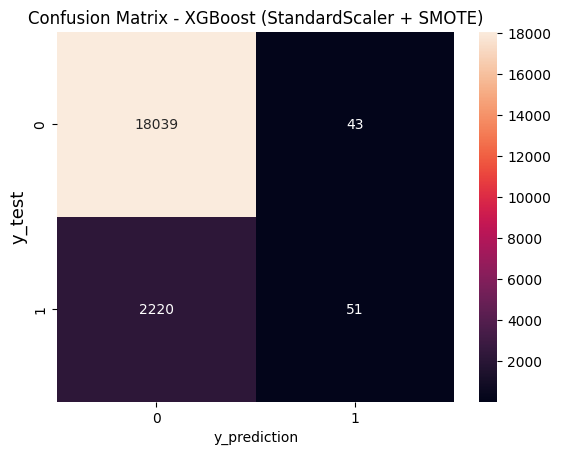

In [71]:
# Visualising Confusion Matrix
confuse_mat = confusion_matrix(y_test, XGB_base_smote_prediction)
sns.heatmap(confuse_mat, annot=True, fmt="g")
plt.ylabel("y_test", fontsize=13)
plt.xlabel("y_prediction")
plt.title("Confusion Matrix - XGBoost (StandardScaler + SMOTE)")
plt.show()

AUC-ROC Score: 0.67%


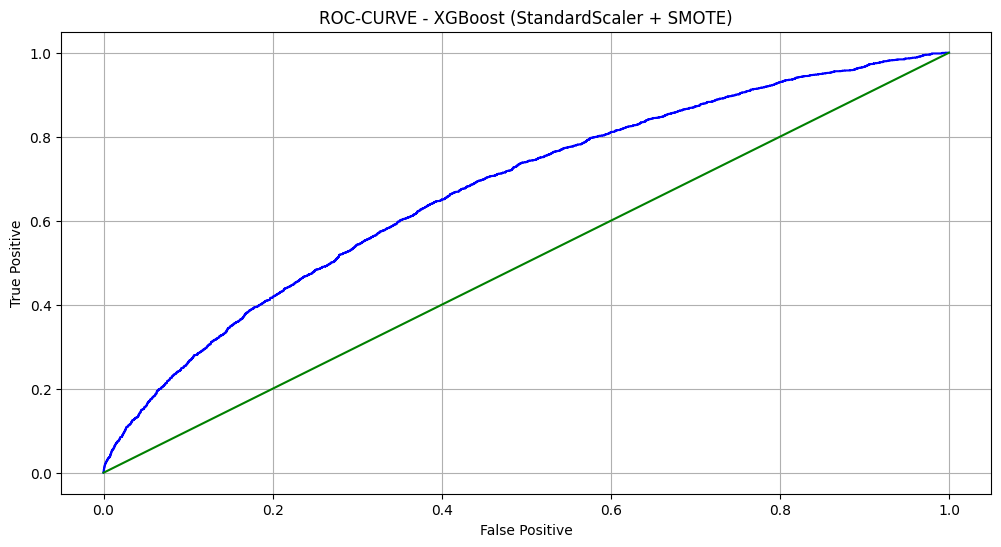

In [72]:
# Visualising AUC-ROC Curve
auc_score = roc_auc_score(y_test, XGB_base_smote_probability)
print(f"AUC-ROC Score: {auc_score:.2f}%")

fpr, tpr, thresholds = roc_curve(y_test, XGB_base_smote_probability)

plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, color="blue", label=f"XGBoost (StandardScaler + SMOTE) (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="green", linestyle="-")
plt.xlabel("False Positive")
plt.ylabel("True Positive")
plt.title("ROC-CURVE - XGBoost (StandardScaler + SMOTE)")
plt.grid(True)
plt.show()

#### Hyperparameter Tuning - RandomizedSearchCV

##### Logistic Regression

In [73]:
# Fine Tuning Model 1 - Logistic Regression
lr_pipeline = ImblearnPipeline([("scaler", StandardScaler()), ("smote", SMOTE(random_state=42)), ("lr", LogisticRegression(random_state=42))])

parameter_distribution_lr = {
    "lr__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "lr__penalty": ["l1", "l2"],
    "lr__solver": ["liblinear"],
    "lr__max_iter": [100, 500, 1000]
}

random_search_lr = RandomizedSearchCV(
    estimator=lr_pipeline, 
    param_distributions=parameter_distribution_lr, 
    cv=5, 
    n_jobs=1,
    n_iter=3, 
    scoring="roc_auc",
    verbose=1,
    random_state=42
)

random_search_lr_result = random_search_lr.fit(X_train, y_train)
print(f"Best parameters: {random_search_lr_result.best_params_}")
print(f"Best AUC-ROC score: {random_search_lr_result.best_score_}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best parameters: {'lr__solver': 'liblinear', 'lr__penalty': 'l2', 'lr__max_iter': 500, 'lr__C': 1.0}
Best AUC-ROC score: 0.610947706943225


In [74]:
# Evaluating the best model on test data
best_lr_model = random_search_lr.best_estimator_
lr_tuned_y_prediction = best_lr_model.predict(X_test)
lr_tuned_y_probability = best_lr_model.predict_proba(X_test)[:, 1]

print("\n Classification Report")
print(classification_report(y_test, lr_tuned_y_prediction))
print("\n AUC-ROC Score")
print(roc_auc_score(y_test, lr_tuned_y_probability))


 Classification Report
              precision    recall  f1-score   support

           0       0.92      0.64      0.75     18082
           1       0.16      0.55      0.25      2271

    accuracy                           0.63     20353
   macro avg       0.54      0.60      0.50     20353
weighted avg       0.83      0.63      0.70     20353


 AUC-ROC Score
0.6276653189728032


##### Random Forest

In [75]:
# Fine Tuning Model 2 - Random Forest
rf_pipeline = ImblearnPipeline([("scaler", StandardScaler()), ("smote", SMOTE(random_state=42)), ("rf", RandomForestClassifier(random_state=42))])

parameter_distribution_rf = {
    "rf__n_estimators": [50, 100, 200, 500],
    "rf__max_features": ["sqrt", "log2"],
    "rf__max_depth": [5, 10, 20],
    "rf__min_samples_split": [5, 10],
    "rf__min_samples_leaf": [1, 2, 3, 4, 5],
    "rf__criterion": ["gini", "entropy"]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf_pipeline, 
    param_distributions=parameter_distribution_rf, 
    cv=5, 
    n_jobs=1,
    n_iter=3, 
    scoring="roc_auc",
    verbose=1,
    random_state=42
)

random_search_rf_result = random_search_rf.fit(X_train, y_train)
print(f"Best parameters: {random_search_rf_result.best_params_}")
print(f"Best AUC-ROC score: {random_search_rf_result.best_score_}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best parameters: {'rf__n_estimators': 500, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 5, 'rf__max_features': 'sqrt', 'rf__max_depth': 20, 'rf__criterion': 'entropy'}
Best AUC-ROC score: 0.6250909881516692


In [76]:
# Evaluating the best model on test data
best_rf_model = random_search_rf.best_estimator_
rf_tuned_y_prediction = best_rf_model.predict(X_test)
rf_tuned_y_probability = best_rf_model.predict_proba(X_test)[:, 1]

print("\n Classification Report")
print(classification_report(y_test, rf_tuned_y_prediction))
print("\n AUC-ROC Score")
print(roc_auc_score(y_test, rf_tuned_y_probability))


 Classification Report
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     18082
           1       0.25      0.08      0.12      2271

    accuracy                           0.87     20353
   macro avg       0.57      0.53      0.53     20353
weighted avg       0.82      0.87      0.84     20353


 AUC-ROC Score
0.6281837021044743


##### XGBoost

In [77]:
# Fine Tuning Model 3 - XGBoost
xgb_pipeline = ImblearnPipeline([("scaler", StandardScaler()), ("smote", SMOTE(random_state=42)), ("xgb", xgb.XGBClassifier(random_state=42, eval_metric="logloss"))])

parameter_distribution_xgb = {
    "xgb__n_estimators": [50, 100, 200],
    "xgb__max_depth": [5, 10],
    "xgb__learning_rate": [0.001, 0.01, 0.1],
    "xgb__subsample": [0.5, 0.6, 0.7]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline, 
    param_distributions=parameter_distribution_xgb, 
    cv=5, 
    n_jobs=1,
    n_iter=3, 
    scoring="roc_auc",
    verbose=1,
    random_state=42
)

random_search_xgb_result = random_search_xgb.fit(X_train, y_train)
print(f"Best parameters: {random_search_xgb_result.best_params_}")
print(f"Best AUC-ROC score: {random_search_xgb_result.best_score_}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best parameters: {'xgb__subsample': 0.5, 'xgb__n_estimators': 100, 'xgb__max_depth': 10, 'xgb__learning_rate': 0.1}
Best AUC-ROC score: 0.6671080753627601


In [78]:
# Evaluating the best model on test data
best_xgb_model = random_search_xgb.best_estimator_
xgb_tuned_y_prediction = best_xgb_model.predict(X_test)
xgb_tuned_y_probability = best_xgb_model.predict_proba(X_test)[:, 1]

print("\n Classification Report")
print(classification_report(y_test, xgb_tuned_y_prediction))
print("\n AUC-ROC Score")
print(roc_auc_score(y_test, xgb_tuned_y_probability))


 Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.46      0.03      0.05      2271

    accuracy                           0.89     20353
   macro avg       0.68      0.51      0.49     20353
weighted avg       0.84      0.89      0.84     20353


 AUC-ROC Score
0.6746179070432652


#### Result Comparison

In [79]:
# Gathering all the necessary results and consolidating them into a table
compiled_total_results = {
    "Models": [
        "Logistic Regression (StandardScaler)",
        "Logistic Regression (StandardScaler + SMOTE)",
        "Logistic Regression (Fine-Tuned)",
        "Random Forest (StandardScaler)",
        "Random Forest (StandardScaler + SMOTE)",
        "Random Forest (Fine-Tuned)",
        "XGBoost (StandardScaler)",
        "XGBoost (StandardScaler + SMOTE)",
        "XGBoost (Fine-Tuned)"
    ],

    "Accuracy": [
        log_reg_base_accuracy,
        log_reg_base_smote_accuracy,
        accuracy_score(y_test, lr_tuned_y_prediction) * 100,
        rand_forest_base_accuracy,
        rand_forest_base_smote_accuracy,
        accuracy_score(y_test, rf_tuned_y_prediction) * 100,
        XGB_base_accuracy,
        XGB_base_smote_accuracy,
        accuracy_score(y_test, xgb_tuned_y_prediction) * 100
    ],

    "AUC-ROC Score": [
        roc_auc_score(y_test, log_reg_base_probability),
        roc_auc_score(y_test, log_reg_base_smote_probability),
        roc_auc_score(y_test, lr_tuned_y_probability),
        roc_auc_score(y_test, rand_forest_base_probability),
        roc_auc_score(y_test, rand_forest_base_smote_probability),
        roc_auc_score(y_test, rf_tuned_y_probability),
        roc_auc_score(y_test, XGB_base_probability),
        roc_auc_score(y_test, XGB_base_smote_probability),
        roc_auc_score(y_test, xgb_tuned_y_probability)
    ],

    "Precision (Class 1)": [
        0.39, 0.16, 0.16, 0.88, 0.64, 0.25, 0.49, 0.54, 0.46
    ],

    "Recall (Class 1)": [
        0.02, 0.55, 0.55, 0.01, 0.01, 0.08, 0.02, 0.02, 0.03
    ],

    "F1-Score (Class 1)": [
        0.04, 0.25, 0.25, 0.01, 0.01, 0.12, 0.04, 0.04, 0.05
    ]
}

# Displaying the results
US_diab_total_results = pd.DataFrame(compiled_total_results)
display(US_diab_total_results)

,Models,Accuracy,AUC-ROC Score,Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
0,Logistic Regression (StandardScaler),88.709281,0.634122,0.39,0.02,0.04
1,Logistic Regression (StandardScaler + SMOTE),63.017737,0.627253,0.16,0.55,0.25
2,Logistic Regression (Fine-Tuned),62.939124,0.627665,0.16,0.55,0.25
3,Random Forest (StandardScaler),88.900899,0.643862,0.88,0.01,0.01
4,Random Forest (StandardScaler + SMOTE),88.876333,0.632162,0.64,0.01,0.01
5,Random Forest (Fine-Tuned),87.127205,0.628184,0.25,0.08,0.12
6,XGBoost (StandardScaler),88.832113,0.678142,0.49,0.02,0.04
7,XGBoost (StandardScaler + SMOTE),88.881246,0.672640,0.54,0.02,0.04
8,XGBoost (Fine-Tuned),88.797720,0.674618,0.46,0.03,0.05


#### SHAP (xAI)

In [80]:
# Overall top performing model was Logistic Regression (Fine-Tuned)
# SHAP will be utilised to better understand the models behavior
explainer = shap.Explainer(best_lr_model.predict, X_train)
shap_values = explainer(X_test)

Background dataset has 81410 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=81410 when initializing the masker.
PermutationExplainer explainer: 20354it [2:23:29,  2.36it/s]                             


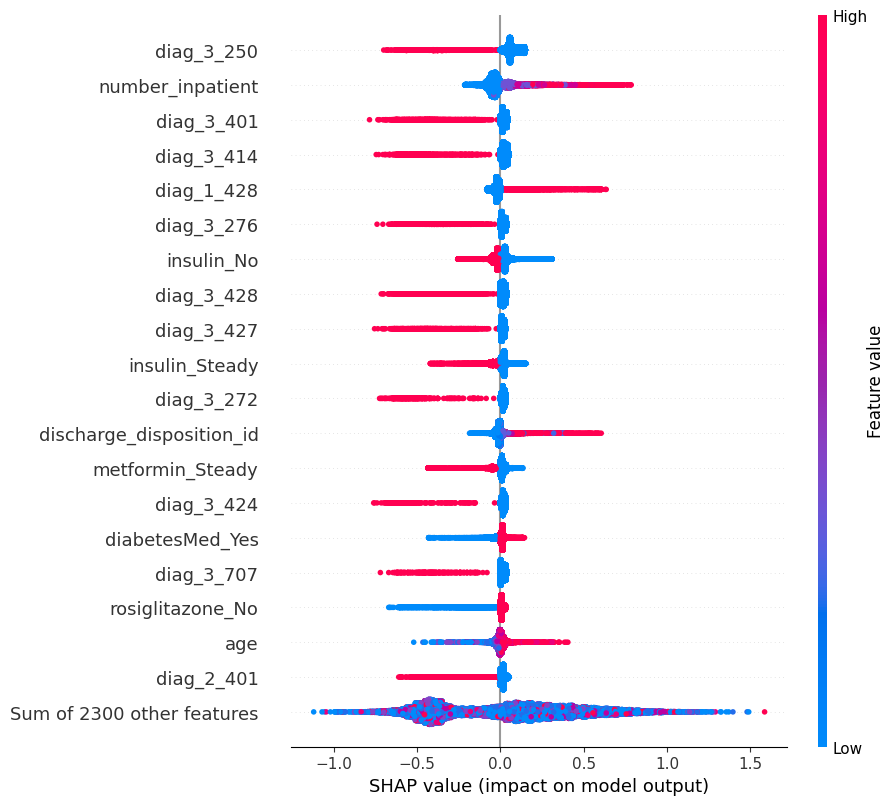

In [81]:
# Visualising a beeswarm plot
shap.plots.beeswarm(shap_values, max_display=20)

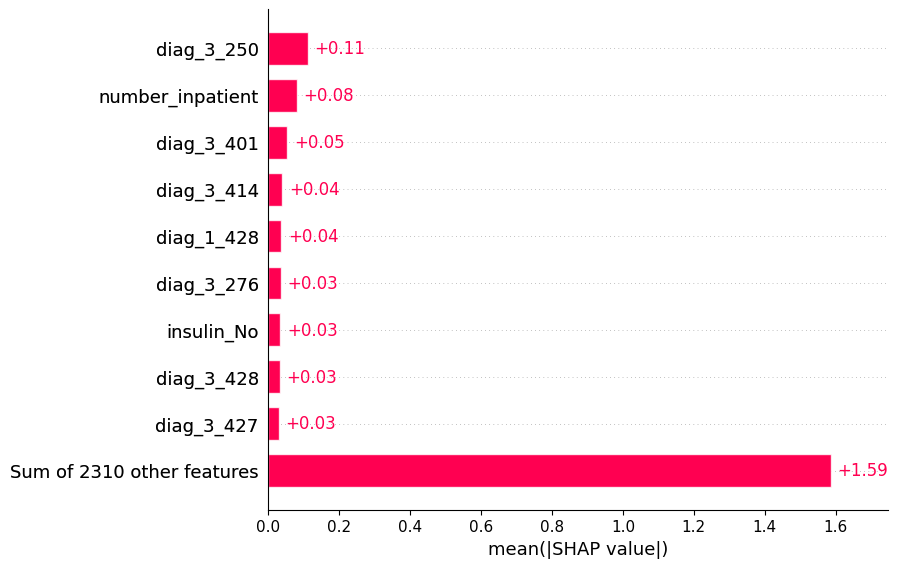

In [ ]:
# Visualising a bar plot
shap.plots.bar(shap_values)

In [83]:
# Visualising a force plot
shap.initjs()
shap.plots.force(shap_values[0])

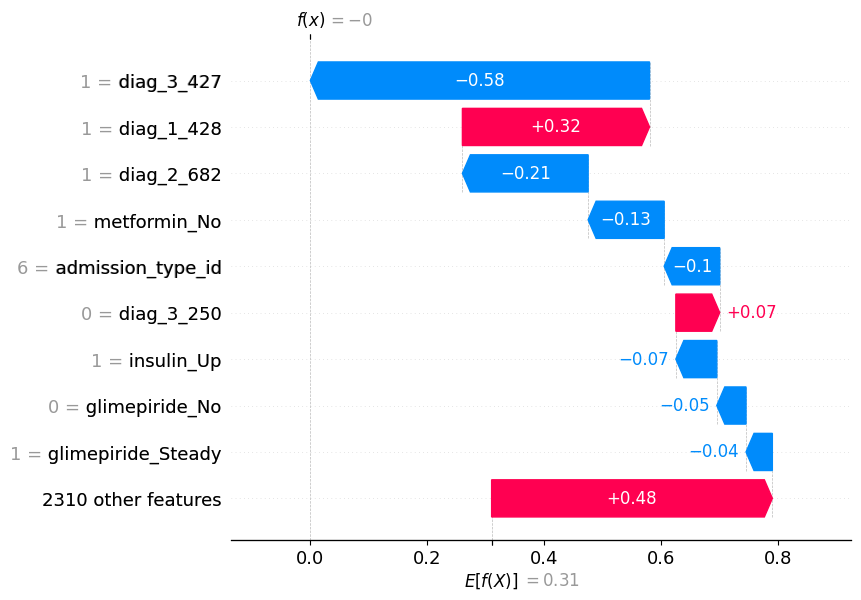

In [86]:
# Visualising a waterfall plot
shap.plots.waterfall(shap_values[0])